# Part 2.5
In order to understand our dataset more deeply we will take some time illustrating the data.

First we find out how many of the ID's are actually present in the last 3 years, then we plot the main contributers for those years.

In [1]:
#Imports
#must pip install holidays
import holidays
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import A_functions 
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

#Our dataframe
final_df = pd.read_csv("cleaned_data/cleaned_df_final_test.csv", parse_dates=["date", "datetime"]) #TEMP NAME, remember to change.
#Variables that we need
final_df["date"] = final_df["date"].dt.date
final_df.info()

imported functions from local folder
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1521079 entries, 0 to 1521078
Data columns (total 38 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   datetime                            1521079 non-null  datetime64[ns]
 1   date                                1521079 non-null  object        
 2   day_of_week                         1521079 non-null  int64         
 3   month                               1521079 non-null  int64         
 4   is_holiday                          1521079 non-null  int64         
 5   rm_id                               1521079 non-null  int64         
 6   daily_weight                        1521079 non-null  float64       
 7   num_orders                          1521079 non-null  float64       
 8   average_orders                      1521079 non-null  float64       
 9   max_orders                     

In [2]:
#3 years from end of dataset
three_years = pd.Timedelta(days=365*3 + 1)

last_date = final_df["datetime"].max()
#last_date = pd.to_datetime(last_date)
three_years_ago = last_date - three_years
#final_df["date"] = pd.to_datetime(final_df["date"])
last_three_years_df = final_df[final_df["datetime"] >= three_years_ago]
print("Verify the split:")
print(last_three_years_df["date"].min())
print(last_three_years_df["date"].max())
print("----")

rm_ids = []
cumsums_per_id = []

for id, group in last_three_years_df.groupby("rm_id", sort=False):
    cumsum_by_start = group["cumulative_weight"].min()
    cumsum_by_end = group["cumulative_weight"].max()
    cumsum_diff = (cumsum_by_end-cumsum_by_start).astype(int).item()
    rm_ids.append(id)
    cumsums_per_id.append(cumsum_diff)

important_ids = pd.DataFrame({"rm_id" : rm_ids})
important_ids["cumsums"] = cumsums_per_id
total_cumsum_3_years = important_ids["cumsums"].sum()
important_ids["proportion"] = important_ids["cumsums"] / total_cumsum_3_years
important_ids = important_ids.sort_values(by="cumsums", ascending=False)
print("We order the most important contributers to the cumulative weight for the three year period.")
print(important_ids.head(5))
print("only 80 rm_ids are present last 3 years.")
print("top 5 stands for ", important_ids.head(n=5)["proportion"].sum(), "%")
print("top 10 stands for ", important_ids.head(n=10)["proportion"].sum(),"%")
print("top 20 stands for ", important_ids.head(n=20)["proportion"].sum(),"%")


Verify the split:
2021-12-19
2024-12-19
----
We order the most important contributers to the cumulative weight for the three year period.
     rm_id   cumsums  proportion
76    2130  52445849    0.201018
172   3781  26317536    0.100872
148   3126  22855930    0.087604
71    2140  19793931    0.075868
177   3865  17997845    0.068983
only 80 rm_ids are present last 3 years.
top 5 stands for  0.5343450926381407 %
top 10 stands for  0.7681635683722216 %
top 20 stands for  0.9319880455431547 %


### Plan:
From our initial exploration, we see that most ID's are unlikely to be present in the next 5 months seing that they have not been present in the last 3 years.

Since a few ID's dominate our cumulative weights we will explore these in more detail.
- Taylored models with specific EDA for the top 5 contenders.
- Taylored models but less tuning for top 20 contenders.
- Generalized models for top 80 contenders. (those present last 3 years)
- Zeroes for the remaing contenders.

Since experimenting is free we can also try other approaches to see if that improves scores (such as using the generalized models for the top contenders too, or including remianing contenders in the prediction)

For now, we will continue our exploration for the top contender: ID 2030.


## Plotting for most common.

In [3]:
def plot_id_simple(id, df):

    
    #Filter for specific ID
    df = df[df["rm_id"] == id]


    x = df["date"]
    y = df["cumulative_weight"]

    sns.set_theme()
    plt.plot(x,y)
    plt.title(label=f"Cumulative weight for ID: {id} in time period {x.min()} to {x.max()}")
    plt.xlabel("Dates")
    plt.ylabel("Cumulative weight")

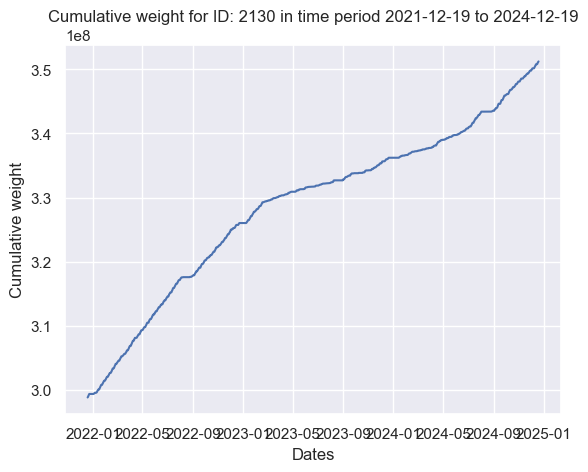

In [4]:
plot_id_simple(2130, last_three_years_df)

### Splitting the model for evaluation and validation 
From what we have seen in our data, there is a fair bit of time-dependancy and also some seasonality. We should consider both when validating our model.

We plan to split our data into
- train and test for training and validating our model.
- train_internal and eval_internal for internal validation by our model (rather than random cross-validation methods)
train_internal and eval_internal are made later in the document.

In [5]:
df_2130 = final_df[final_df["rm_id"] == 2130]

#Our first split for test data is 2024-09-01 to our last historical date (2024-12-19)
test_split_start = pd.Timestamp(year=2024, month=9, day=1).date()
#Our second split (for internal model validation) is 2024-01-01 to 2024-05-01
eval_split_start = pd.Timestamp(year=2024, month=1, day=1).date()
eval_split_end = pd.Timestamp(year=2024, month=5, day=1).date()

train_full_2030 = df_2130[df_2130["date"] < test_split_start]
test_holdout_2030 = df_2130[df_2130["date"] >= test_split_start]



#Verify:
print("train_full starts at ",train_full_2030["date"].min() , "and ends at ", train_full_2030["date"].max())
print("test_holdout starts at ", test_holdout_2030["date"].min(), "and ends at ", test_holdout_2030["date"].max())


train_full starts at  2004-06-15 and ends at  2024-08-31
test_holdout starts at  2024-09-01 and ends at  2024-12-19


# Model considerations:
When creating our model, we have some options, each with their own pro's and con's. Different approaches might be suitable for different ID's
### Option 1. Modelling Increments and sum later for cumulative weight
- Might capture receival dynamics
- Scale of individual receivals might be easier for some models to handle
- For some ID's with many zeroes it can be hard to make good predictions.
- Hard to pinpoint exact receival dates. Can be extra detrimental since overestimation penalization is skewed.
### Option 2. Modelling increments but recursivly calculating cumulative weight for internal validation. WE WILL NOT IMPLEMENT THIS!
- Perhaps some of the benefits of Option 1
- Recursion during model prediction and training is likely to be very slow.
### Option 3. Modelling Cumulative weights directly
- In line with final submission
- Cares less about exact timing of receivals
- Might not catch receival mechanics
### Option 4. Model averages and distribute later (using option 3 as baseline)
- Since pinpointing dates are hard (at least for some ID's), we might have bad "daily prediction" but have a good idea for sum of predictions over a larger window.
- Distributing can be done unevenly (since overestimation is penalized more we can "backload" the distribution).
- Window sizes can be determined by frequency of deliveries
- Might be too generalizing, and not capture details.

### We decide what features should be used for predictions:

In [36]:
#Comment out those we do not use.
feature_columns = [
    "day_of_week", 
    "month", 
    "is_holiday",
    #"rolling_600_static",
    #"rolling_300_static",
    #"rolling_100_static",
    #"rolling_30_static",
    #"rolling_7_static",
    #"shifted_30_rolling_7_static",
    #"shifted_7_rolling_7_static" ,
    "shifted_200_rolling_7",
    "shifted_200_rolling_30",
    "shifted_200_rolling_100",
    "shifted_500_rolling_30",
    "shifted_500_rolling_100",
    "shifted_500_rolling_300",
    #"cumulative_rolling_600_static",
    #"cumulative_rolling_300_static",
    #"cumulative_rolling_100_static",
    #"cumulative_rolling_30_static",
    #"cumulative_rolling_7_static",
    #"cumulative_shifted_30_rolling_7_static",
    #"cumulative_shifted_7_rolling_7_static" ,
    "cumulative_shifted_200_rolling_7",
    "cumulative_shifted_200_rolling_30",
    "cumulative_shifted_200_rolling_100",
    "cumulative_shifted_500_rolling_30",
    "cumulative_shifted_500_rolling_100",
    "cumulative_shifted_500_rolling_300",
    ]

#Choose one or the other.
target_value = [
    #"cumulative_weight"
    "daily_weight"
]

# Preparing Dataframe for prediction:

In [7]:
def prepare_common_map(start_date, end_date):

    prediction_range = pd.date_range(start=start_date, end=end_date)

    #Generic time-series data
    test_map = pd.DataFrame({"datetime" : prediction_range})
    test_map["datetime"] = pd.to_datetime(test_map["datetime"]).dt.tz_localize(None)
    test_map["datetime"] = test_map["datetime"].dt.normalize()
    test_map["date"] = test_map["datetime"].dt.date
    test_map["day_of_week"] = test_map["datetime"].dt.dayofweek
    test_map["month"] = test_map["datetime"].dt.month

    #Get all holidays
    years = list(range(2023, 2025))
    all_holidays = holidays.Norway(years = years)
    
    #Convert type
    all_holidays = list(all_holidays.keys())
    all_holidays = pd.to_datetime(all_holidays)
    all_holidays = pd.DataFrame({"holidays" : all_holidays})
    #Mark holidays
    test_map["is_holiday"] = test_map["datetime"].isin(all_holidays["holidays"])
    test_map["is_holiday"] = test_map["is_holiday"].astype(int)
    print(test_map["is_holiday"].sum() ," days are marked as holidays")
    return test_map


start_date = test_holdout_2030["date"].min()
end_date = test_holdout_2030["date"].max()
common_map = prepare_common_map(start_date, end_date)


0  days are marked as holidays


In [17]:
def prepare_full_map(common_map, train_df):

    valid_ids = train_df["rm_id"].unique()
    extended_common_map = pd.concat([common_map] * len(valid_ids), ignore_index=True)
    first_prediction_date = common_map["datetime"].min()

    last_prediction_date = common_map["datetime"].max()
    date_range = pd.date_range(start=first_prediction_date, end=last_prediction_date)

    #We add som shifted date ranges
    #500
    fivehundred_days = pd.Timedelta(days=500)
    first_date_shift_500 = first_prediction_date - fivehundred_days
    last_date_shift_500 = last_prediction_date - fivehundred_days
    shifted_500_range = pd.date_range(start=first_date_shift_500, end=last_date_shift_500)
    shifted_500_range = shifted_500_range.strftime('%Y-%m-%d')
    shifted_500_range = pd.DataFrame({"date_str" : shifted_500_range})
    #200
    twohundred_days = pd.Timedelta(days=200)
    first_date_shift_200 = first_prediction_date - twohundred_days
    last_date_shift_200 = last_prediction_date - twohundred_days
    shifted_200_range = pd.date_range(start=first_date_shift_200, end=last_date_shift_200)
    shifted_200_range = shifted_200_range.strftime('%Y-%m-%d')

    groups = []
    for id,group in train_df.groupby("rm_id", sort=False):

        id_map = pd.DataFrame({"datetime" : date_range})
        #print("length of id_map:", len(id_map))
        #print("ID_map head: ", id_map.head())

        group["date_str"] = group["datetime"].astype(str)
        #Dyanamic
        rolling_500_df = group[(group["datetime"] <= last_date_shift_500) & (group["datetime"] >= first_date_shift_500)]
        rolling_200_df = group[(group["datetime"] <= last_date_shift_200) & (group["datetime"] >= first_date_shift_200)]
        rolling_500_df = rolling_500_df.reset_index()
        print("shifted 500 length:", len(shifted_500_range))
        print("shifted 500 top:",shifted_500_range[:5])
        print("shifted 500 bot:",shifted_500_range[-5:])
        print("rolling_500_df len: ", len(rolling_500_df))
        print("rolling_500_dfhead: ", rolling_500_df["rolling_300"].head())
        print("rolling_500_df tail: ", rolling_500_df["rolling_300"].tail())
        rolling_500_df.to_csv("test_rolling_500.csv", index = False)
        #increments
        id_map["shifted_500_rolling_300"] = rolling_500_df["rolling_300"]
        id_map["shifted_500_rolling_100"] = rolling_500_df["rolling_100"]
        id_map["shifted_500_rolling_30"] = rolling_500_df["rolling_30"]
        id_map["shifted_200_rolling_100"] = rolling_200_df["rolling_100"]
        id_map["shifted_200_rolling_30"] = rolling_200_df["rolling_30"]
        id_map["shifted_200_rolling_7"] = rolling_200_df["rolling_7"]
        print(rolling_500_df["shifted_500_rolling_300"].head())
        print(id_map["shifted_500_rolling_300"].head())
        #cumulative
        id_map["cumulative_shifted_500_rolling_300"] = rolling_500_df["cumulative_rolling_300"]
        id_map["cumulative_shifted_500_rolling_100"] = rolling_500_df["cumulative_rolling_100"]
        id_map["cumulative_shifted_500_rolling_30"] = rolling_500_df["cumulative_rolling_30"]
        id_map["cumulative_shifted_200_rolling_100"] = rolling_200_df["cumulative_rolling_100"]
        id_map["cumulative_shifted_200_rolling_30"] = rolling_200_df["cumulative_rolling_30"]
        id_map["cumulative_shifted_200_rolling_7"] = rolling_200_df["cumulative_rolling_7"]
 
        #Static
        #increments
        id_map["rm_id"] = id
        id_map["rolling_600_static"] = group["rolling_600"].iloc[-1]
        id_map["rolling_300_static"] = group["rolling_300"].iloc[-1]
        id_map["rolling_100_static"] = group["rolling_100"].iloc[-1]
        id_map["rolling_30_static"] = group["rolling_30"].iloc[-1]
        id_map["rolling_7_static"] = group["rolling_7"].iloc[-1]
        id_map["shifted_30_rolling_7_static"] = group["shifted_30_rolling_7"].iloc[-1]
        id_map["shifted_7_rolling_7_static"] = group["shifted_7_rolling_7"].iloc[-1]
        

        #cumulative
        id_map["cumulative_rolling_600_static"] = group["cumulative_rolling_600"].iloc[-1]
        id_map["cumulative_rolling_300_static"] = group["cumulative_rolling_300"].iloc[-1]
        id_map["cumulative_rolling_100_static"] = group["cumulative_rolling_100"].iloc[-1]
        id_map["cumulative_rolling_30_static"] = group["cumulative_rolling_30"].iloc[-1]
        id_map["cumulative_rolling_7_static"] = group["cumulative_rolling_7"].iloc[-1]
        id_map["cumulative_shifted_30_rolling_7_static"] = group["cumulative_shifted_30_rolling_7"].iloc[-1]
        id_map["cumulative_shifted_7_rolling_7_static"] = group["cumulative_shifted_7_rolling_7"].iloc[-1]

        groups.append(id_map)
        

    id_maps = pd.concat(groups, ignore_index=True)
    id_maps.to_csv("test_id_maps.csv", index = False)
    #print(id_maps.head())
    full_map = pd.concat([extended_common_map, id_maps], axis=1)


    return valid_ids, full_map

(ids, full_map) = prepare_full_map(common_map, train_full_2030)
#print(full_map.head(n=1))
#print(full_map.tail(n=1))

shifted 500 length: 110
shifted 500 top:      date_str
0  2023-04-20
1  2023-04-21
2  2023-04-22
3  2023-04-23
4  2023-04-24
shifted 500 bot:        date_str
105  2023-08-03
106  2023-08-04
107  2023-08-05
108  2023-08-06
109  2023-08-07
rolling_500_df len:  110
rolling_500_dfhead:  0    55472.363333
1    55909.473333
2    55909.473333
3    55457.420000
4    55162.303333
Name: rolling_300, dtype: float64
rolling_500_df tail:  105    39208.383333
106    39238.916667
107    39238.916667
108    38979.423333
109    38628.586667
Name: rolling_300, dtype: float64
0    74545.200000
1    74524.890000
2    73913.726667
3    73849.920000
4    74295.116667
Name: shifted_500_rolling_300, dtype: float64
0    55472.363333
1    55909.473333
2    55909.473333
3    55457.420000
4    55162.303333
Name: shifted_500_rolling_300, dtype: float64


In [18]:
train_full_2030.to_csv("test_train_full_2030.csv", index = False)
full_map.to_csv("test_prediction_map.csv", index = False)

### Since our trainig data is further split into train_internal and eval_internal

In [19]:
def add_statics_train(train_internal):
    #increment
    train_internal["rolling_600_static"] = train_internal["rolling_600"].iloc[-1]
    train_internal["rolling_300_static"] = train_internal["rolling_300"].iloc[-1]
    train_internal["rolling_100_static"] = train_internal["rolling_100"].iloc[-1]
    train_internal["rolling_30_static"] = train_internal["rolling_30"].iloc[-1]
    train_internal["rolling_7_static"] = train_internal["rolling_7"].iloc[-1]
    train_internal["shifted_30_rolling_7_static"] = train_internal["shifted_30_rolling_7"].iloc[-1]
    train_internal["shifted_7_rolling_7_static"] = train_internal["shifted_7_rolling_7"].iloc[-1]
    #cumulative
    train_internal["cumulative_rolling_600_static"] = train_internal["cumulative_rolling_600"].iloc[-1]
    train_internal["cumulative_rolling_300_static"] = train_internal["cumulative_rolling_300"].iloc[-1]
    train_internal["cumulative_rolling_100_static"] = train_internal["cumulative_rolling_100"].iloc[-1]
    train_internal["cumulative_rolling_30_static"] = train_internal["cumulative_rolling_30"].iloc[-1]
    train_internal["cumulative_rolling_7_static"] = train_internal["cumulative_rolling_7"].iloc[-1]
    train_internal["cumulative_shifted_30_rolling_7_static"] = train_internal["cumulative_shifted_30_rolling_7"].iloc[-1]
    train_internal["cumulative_shifted_7_rolling_7_static"] = train_internal["cumulative_shifted_7_rolling_7"].iloc[-1]

    return train_internal


In [20]:
def add_statics_eval(eval_internal):
    old_column_names = [
        "rolling_600",
        "rolling_300",
        "rolling_100",
        "rolling_30",
        "rolling_7",
        "shifted_30_rolling_7",
        "shifted_7_rolling_7",
        "cumulative_rolling_600",
        "cumulative_rolling_300",
        "cumulative_rolling_100",
        "cumulative_rolling_30",
        "cumulative_rolling_7",
        "cumulative_shifted_30_rolling_7",
        "cumulative_shifted_7_rolling_7",
    ]

    new_column_names = [
        "rolling_600_static",
        "rolling_300_static",
        "rolling_100_static",
        "rolling_30_static",
        "rolling_7_static",
        "shifted_30_rolling_7_static",
        "shifted_7_rolling_7_static",
        "cumulative_rolling_600_static",
        "cumulative_rolling_300_static",
        "cumulative_rolling_100_static",
        "cumulative_rolling_30_static",
        "cumulative_rolling_7_static",
        "cumulative_shifted_30_rolling_7_static",
        "cumulative_shifted_7_rolling_7_static",
    ]

    eval_internal.rename(columns = dict(zip(old_column_names, new_column_names)), inplace = True)
    
    return eval_internal




In [37]:
train_internal_2030 = train_full_2030[train_full_2030["date"] < eval_split_start]
eval_internal_2030 = train_full_2030[(train_full_2030["date"] >= eval_split_start) & (train_full_2030["date"] <= eval_split_end) ]

train_internal_2030 = add_statics_train(train_internal_2030)
eval_internal_2030 = add_statics_eval(eval_internal_2030)
train_full_2030 = add_statics_train(train_full_2030)

print("train_internal starts at ",train_internal_2030["date"].min() , "and ends at ",train_internal_2030["date"].max() )
print("eval_internal starts at ",eval_internal_2030["date"].min() , "and ends at ", eval_internal_2030["date"].max())

X_train_internal = train_internal_2030[feature_columns]
y_train_internal = train_internal_2030[target_value]
X_eval_internal = eval_internal_2030[feature_columns]
y_eval_internal = eval_internal_2030[target_value]

train_internal starts at  2004-06-15 and ends at  2023-12-31
eval_internal starts at  2024-01-01 and ends at  2024-05-01


C:\Users\aksel\AppData\Local\Temp\ipykernel_15020\114798075.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_internal["rolling_600_static"] = train_internal["rolling_600"].iloc[-1]
C:\Users\aksel\AppData\Local\Temp\ipykernel_15020\114798075.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_internal["rolling_300_static"] = train_internal["rolling_300"].iloc[-1]
C:\Users\aksel\AppData\Local\Temp\ipykernel_15020\114798075.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [38]:
full_map.to_csv("test_prediction_map.csv", index = False)
train_internal_2030.to_csv("test_train_internal_2030.csv", index = False)
eval_internal_2030.to_csv("test_eval_internal_2030.csv", index = False)

## Initialize model:


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3082
[LightGBM] [Info] Number of data points in the train set: 7139, number of used features: 15
[LightGBM] [Info] Start training from score 47095.338003


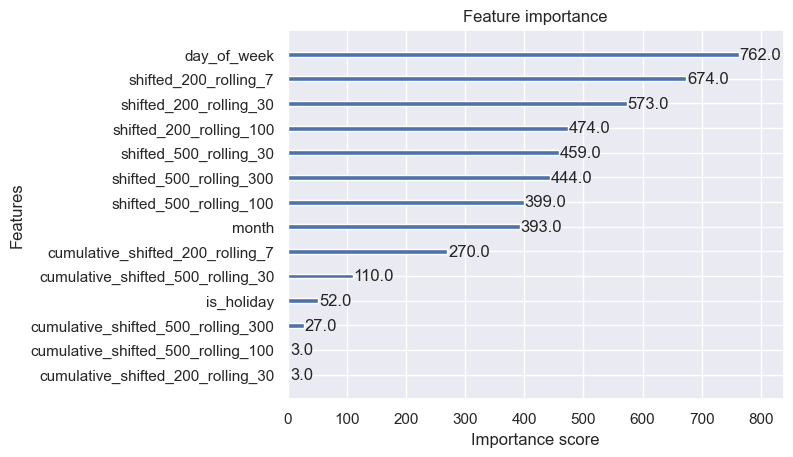

In [39]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1
)

lgb_model = lgb.LGBMRegressor()

cb_model = CatBoostRegressor(verbose=False)

#rf_model = RandomForestRegressor()

#hgb_model = HistGradientBoostingRegressor()


xgb_model.fit(X_train_internal, y_train_internal, eval_set=[(X_eval_internal, y_eval_internal)], verbose=False)
xgb_best_params = xgb_model.get_params()
final_xgb_model = xgb.XGBRegressor(**xgb_best_params)
final_xgb_model.fit(train_full_2030[feature_columns], train_full_2030[target_value])


lgb_model.fit(X_train_internal, y_train_internal, eval_set=[(X_eval_internal, y_eval_internal)])
cb_model.fit(X_train_internal, y_train_internal, eval_set=[(X_eval_internal, y_eval_internal)], early_stopping_rounds = 50)
#rf_model.fit(train_full_2030[feature_columns], train_full_2030["cumulative_weight"])
#hgb_model.fit(train_full_2030[feature_columns], train_full_2030["cumulative_weight"])
xgb.plot_importance(xgb_model)
plt.show()


In [48]:
xgb_predictions = final_xgb_model.predict(full_map[feature_columns])
lgb_predictions = lgb_model.predict(full_map[feature_columns])
cb_predictions = cb_model.predict(full_map[feature_columns])
#rf_predictions = rf_model.predict(full_map[feature_columns])
#hgb_predictions = hgb_model.predict(full_map[feature_columns])

prediction_map = full_map.copy()
prediction_map["xgb_predicts"] = xgb_predictions
prediction_map["lgb_predicts"] = lgb_predictions
prediction_map["cb_predicts"] = cb_predictions
prediction_map["cumulative_xgb_predicts"] = xgb_predictions.cumsum() + train_full_2030["cumulative_weight"].iloc[-1]
prediction_map["cumulative_lgb_predicts"] = lgb_predictions.cumsum() + train_full_2030["cumulative_weight"].iloc[-1]
prediction_map["cumulative_cb_predicts"] = cb_predictions.cumsum() + train_full_2030["cumulative_weight"].iloc[-1]
prediction_map["cumulative_cb_predicts"] 
#prediction_map["rf_predicts"] = rf_predictions
#prediction_map["hgb_predicts"] = hgb_predictions

print(prediction_map.head())

    datetime        date  day_of_week  month  is_holiday   datetime  \
0 2024-09-01  2024-09-01            6      9           0 2024-09-01   
1 2024-09-02  2024-09-02            0      9           0 2024-09-02   
2 2024-09-03  2024-09-03            1      9           0 2024-09-03   
3 2024-09-04  2024-09-04            2      9           0 2024-09-04   
4 2024-09-05  2024-09-05            3      9           0 2024-09-05   

   shifted_500_rolling_300  shifted_500_rolling_100  shifted_500_rolling_30  \
0             55472.363333                 44325.44            21751.566667   
1             55909.473333                 44872.87            25898.666667   
2             55909.473333                 43587.01            24719.333333   
3             55457.420000                 42555.62            23226.666667   
4             55162.303333                 42835.22            24158.666667   

   shifted_200_rolling_100  ...  cumulative_rolling_30_static  \
0                      NaN  ...  

In [ ]:
future_predict_start_date = pd.Timestamp(year=2024, month=12, day=20).date()
future_predict_end_date = pd.Timestamp(year=2025, month=5, day=31).date()

eval_split = pd.Timestamp(year=2024, month=10, day=25).date()

future_train_full_2030 = df_2130[df_2130["date"] < eval_split]
future_eval_full_2030 = df_2130[df_2130["date"] >= eval_split]

df_2130 = add_statics_train(df_2130)
future_train_full_2030 = add_statics_train(future_train_full_2030)
future_eval_full_2030 = add_statics_eval(future_eval_full_2030)

X_future_train = future_train_full_2030[feature_columns]
y_future_train = future_train_full_2030[target_value]
X_future_eval = future_eval_full_2030[feature_columns]
y_future_eval = future_eval_full_2030[target_value]

future_common_map = prepare_common_map(future_predict_start_date, future_predict_end_date)
future_full_map = prepare_full_map(future_common_map, future_train_full_2030)

future_xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1
)

future_xgb_model.fit(X_future_train, y_future_train, eval_set=[(X_future_eval, y_future_eval)], verbose=False)
future_xgb_best_params = future_xgb_model.get_params()
future_final_xgb_model = xgb.XGBRegressor(**future_xgb_best_params)
future_final_xgb_model.fit(df_2130[feature_columns], df_2130[target_value])






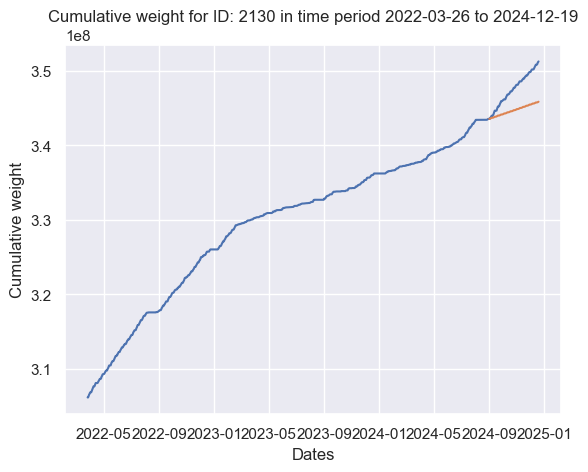

In [50]:
#prediction_map["rm_id"] = 2130
plot_id_simple(2130, df_2130.tail(n=1000))
x = prediction_map["date"]
y = prediction_map["xgb_predicts"]
y2 = prediction_map["lgb_predicts"]
y3 = prediction_map["cb_predicts"]
z = prediction_map["cumulative_xgb_predicts"]
z2 = prediction_map["cumulative_lgb_predicts"]
z3 = prediction_map["cumulative_cb_predicts"]
#y4 = prediction_map["rf_predicts"]
#y5 = prediction_map["hgb_predicts"]
#plt.plot(x,y)
#plt.plot(x,y2)
#plt.plot(x,y3)
plt.plot(x,z)
#plt.plot(x,z2)
#plt.plot(x,z3)
#plt.plot(x,y4)
#plt.plot(x,y5)